In [1]:
import os
import json
import math
import re
import sqlite3
import time
from collections import Counter, defaultdict
from typing import Any, TypedDict

import numpy as np
from openai import OpenAI

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY before running this notebook: export OPENAI_API_KEY=sk-...")

client = OpenAI(api_key=OPENAI_API_KEY)
EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-4o-mini")

print(f"OpenAI ready. Chat model: {CHAT_MODEL}; embedding model: {EMBED_MODEL}")

OpenAI ready. Chat model: gpt-4o-mini; embedding model: text-embedding-3-small


In [2]:
CORPUS = [
    {
        "id": "pods",
        "source": "pods.md",
        "text": "A Kubernetes Pod is the smallest deployable unit. Containers in a Pod share network, storage volumes, and lifecycle. Use kubectl describe pod and kubectl logs to debug Pod behavior.",
    },
    {
        "id": "deployment",
        "source": "deployment.md",
        "text": "A Deployment manages ReplicaSets and rolling updates. Use kubectl rollout status deployment/nginx to watch progress and kubectl rollout undo deployment/nginx to roll back a bad release.",
    },
    {
        "id": "service",
        "source": "service.md",
        "text": "A Service gives stable networking for Pods. ClusterIP is internal, NodePort exposes a port on nodes, and LoadBalancer asks the cloud provider for an external endpoint.",
    },
    {
        "id": "probes",
        "source": "probes.md",
        "text": "Readiness probes decide when a Pod can receive traffic. Liveness probes restart stuck containers. Startup probes protect slow-starting applications from premature restarts.",
    },
    {
        "id": "secrets",
        "source": "secrets.md",
        "text": "Kubernetes Secrets store sensitive values such as passwords, tokens, and keys. Enable encryption at rest, restrict RBAC, and avoid printing secret data in logs.",
    },
    {
        "id": "taints",
        "source": "taints.md",
        "text": "Taints repel Pods from nodes. Tolerations allow selected Pods to schedule onto tainted nodes. A NoSchedule taint blocks Pods that lack a matching toleration.",
    },
    {
        "id": "hpa",
        "source": "hpa.md",
        "text": "The HorizontalPodAutoscaler increases or decreases replicas based on CPU, memory, or custom metrics so an application can handle more traffic automatically.",
    },
]

NOISE_DOCS = [
    {"id": "noise-cache", "source": "cache-paper.md", "text": "Cache-aware matrix multiplication improves locality in CPU memory hierarchies and reduces cache misses."},
    {"id": "noise-graph", "source": "graph-paper.md", "text": "Graph partitioning algorithms optimize edge cuts in distributed computation workloads."},
]

print(f"Inline corpus loaded: {len(CORPUS)} K8s snippets + {len(NOISE_DOCS)} noise snippets")

Inline corpus loaded: 7 K8s snippets + 2 noise snippets


In [3]:
def embed_texts(texts: list[str]) -> list[list[float]]:
    response = client.embeddings.create(model=EMBED_MODEL, input=texts)
    return [item.embedding for item in response.data]


def cosine(a: list[float], b: list[float]) -> float:
    av = np.array(a, dtype=float)
    bv = np.array(b, dtype=float)
    denom = np.linalg.norm(av) * np.linalg.norm(bv)
    return float(np.dot(av, bv) / denom) if denom else 0.0


def dense_search(question: str, docs: list[dict[str, str]], top_k: int = 3) -> list[dict[str, Any]]:
    vectors = embed_texts([question] + [d["text"] for d in docs])
    qv, doc_vectors = vectors[0], vectors[1:]
    ranked = []
    for doc, dv in zip(docs, doc_vectors):
        ranked.append({**doc, "score": cosine(qv, dv)})
    return sorted(ranked, key=lambda d: d["score"], reverse=True)[:top_k]


def answer_with_context(question: str, chunks: list[dict[str, Any]]) -> str:
    context = "\n\n".join(f"SOURCE: {c['source']}\n{c['text']}" for c in chunks)
    messages = [
        {"role": "system", "content": "Answer only from the provided Kubernetes context. Cite source names inline."},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
    ]
    response = client.chat.completions.create(model=CHAT_MODEL, messages=messages, temperature=0)
    return response.choices[0].message.content

In [4]:
def reflect(question: str, answer: str) -> dict[str, Any]:
    prompt = f"""Critique the answer for usefulness and specificity.
Return JSON with keys: score (0-1), needs_retry (boolean), refined_question (string), reason.

Original question: {question}
Answer: {answer}"""

    response = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0,
    )

    data = json.loads(response.choices[0].message.content)
    data.setdefault("refined_question", question)
    return data



In [5]:
def route_after_reflection(state: dict[str, Any]) -> str:
    if state["iterations"] >= 2:
        return "done"
    if state["reflection"].get("needs_retry") and float(state["reflection"].get("score", 1)) < 0.85:
        return "retry"
    return "done"

In [6]:
from langgraph.graph import StateGraph, END

class SelfRAGState(TypedDict):
    question: str
    working_question: str
    chunks: list[dict[str, Any]]
    answer: str
    reflection: dict[str, Any]
    iterations: int

In [7]:
def retrieve(state: SelfRAGState) -> SelfRAGState:
    return {**state, "chunks": dense_search(state["working_question"], CORPUS + NOISE_DOCS, top_k=3)}

def generate(state: SelfRAGState) -> SelfRAGState:
    return {**state, "answer": answer_with_context(state["working_question"], state["chunks"])}

def critique(state: SelfRAGState) -> SelfRAGState:
    return {**state, "reflection": reflect(state["working_question"], state["answer"])}

def refine(state: SelfRAGState) -> SelfRAGState:
    return {
        **state,
        "working_question": state["reflection"].get("refined_question", state["working_question"]),
        "iterations": state["iterations"] + 1,
    }

In [8]:
g = StateGraph(SelfRAGState)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_node("critique", critique)
g.add_node("refine", refine)

In [9]:
g.set_entry_point("retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", "critique")
g.add_conditional_edges("critique", route_after_reflection, {"retry": "refine", "done": END})
g.add_edge("refine", "retrieve")

In [10]:
self_rag_graph = g.compile()

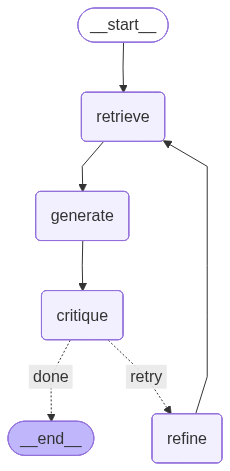

In [11]:
from IPython.display import Image, display


display(Image(self_rag_graph.get_graph().draw_mermaid_png()))

In [12]:
start = {"question": "how do i scale", "working_question": "how do i scale", "chunks": [], "answer": "", "reflection": {}, "iterations": 0}
result = self_rag_graph.invoke(start)

In [13]:
result

{'question': 'how do i scale',
 'working_question': 'how do i scale',
 'chunks': [{'id': 'hpa',
   'source': 'hpa.md',
   'text': 'The HorizontalPodAutoscaler increases or decreases replicas based on CPU, memory, or custom metrics so an application can handle more traffic automatically.',
   'score': 0.3640960903757071},
  {'id': 'deployment',
   'source': 'deployment.md',
   'text': 'A Deployment manages ReplicaSets and rolling updates. Use kubectl rollout status deployment/nginx to watch progress and kubectl rollout undo deployment/nginx to roll back a bad release.',
   'score': 0.19408678201610105},
  {'id': 'noise-graph',
   'source': 'graph-paper.md',
   'text': 'Graph partitioning algorithms optimize edge cuts in distributed computation workloads.',
   'score': 0.18835037994993536}],
 'answer': 'To scale your application in Kubernetes, you can use the HorizontalPodAutoscaler (HPA). The HPA automatically adjusts the number of replicas based on CPU, memory, or custom metrics, allow

In [14]:
print("Final working question:", result["working_question"])
print("Iterations:", result["iterations"])
print("Reflection:", result["reflection"])
print(result["answer"])

Final working question: how do i scale
Iterations: 0
Reflection: {'score': 0.8, 'needs_retry': False, 'refined_question': 'How can I effectively scale my application in Kubernetes?', 'reason': 'The answer provides useful information about scaling in Kubernetes, including both automatic and manual methods. However, it could be more specific by including examples of when to use HPA versus manual scaling, as well as potential pitfalls or considerations when scaling applications.'}
To scale your application in Kubernetes, you can use the HorizontalPodAutoscaler (HPA). The HPA automatically adjusts the number of replicas based on CPU, memory, or custom metrics, allowing your application to handle varying traffic loads efficiently (source: hpa.md). 

If you want to manually scale your application, you can modify the number of replicas in your Deployment configuration. You can use the command `kubectl scale deployment/<deployment-name> --replicas=<desired-replica-count>` to set the desired nu